# Exercise 2

<div class="alert alert-info">

## Information
- Your solutions to this exercise need to be **submitted by the end of the week**. 
- Consider the rules regarding teamwork, expectations, and late submissions.
- Also remember and follow the **Generative AI Policy** of our course.
</div>

<div class="alert alert-info">

# Instructions

- Install the package `seaborn` and `matplotlib` in your course-specific virtual environment, if you have not done so already.
- Store the data file `used_cars_sample.csv` either in the same directory as the current Jupyter notebook, or in a subdirectory named `data`.
- Most of the questions requires only Python code as an answer. Ocasionally, questions may require also a more extensive textual answer. Then `Markdown` is often a good choice.
- Submit only the Jupyter Notebook on Moodle, not the data set. You do not need to state your name or student ID in your submissions.
</div>

## Task 1: Setup

Import required packages 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib

Read in the data set `used_cars_sample.csv` and print the shape of the dataset

In [2]:
cwd = pathlib.Path.cwd()
data = cwd.joinpath("data")

In [3]:
df = pd.read_csv(data.joinpath("used_cars_sample.csv"))

Display the first five rows

In [4]:
df.head()

,brand,model,color,year,price,horsepower,transmission_type,fuel_type,fuel_consumption,mileage,offer_description
0,mercedes-benz,Mercedes-Benz E 200,grey,2016,74900,184,Automatic,Petrol,6.1,45741.0,Coupe AMG*7G*LED*MASSAGE*TEMPO*NAVI*LEDER
1,audi,Audi A4,silver,2018,21500,190,Automatic,Diesel,6.2,144933.0,Av 40 TDI qu sport ACC AHK PANO VC RFK
2,volkswagen,Volkswagen Touran,black,2022,37390,150,Automatic,Petrol,6.6,125.0,1.5 TSI DSG Highline 7-Sitzer NAVI LED
3,ford,Ford B-Max,white,2016,14990,101,Manual,Petrol,4.9,36246.0,1.0 EcoBoost Titanium AAC Navi SHZ PDC
4,toyota,Toyota C-HR,red,2022,30990,184,Automatic,Hybrid,0.0,7500.0,2.0 Hybrid Team Deutschland


The column `year` represents the year of registration of the used car. Calculate the age of the car in years, assuming that the data was collected in 2023

In [5]:
df["age"] = 2023 - df["year"]
df[["brand","model","year","age"]].head()

,brand,model,year,age
0,mercedes-benz,Mercedes-Benz E 200,2016,7
1,audi,Audi A4,2018,5
2,volkswagen,Volkswagen Touran,2022,1
3,ford,Ford B-Max,2016,7
4,toyota,Toyota C-HR,2022,1


Inspect your data: Which data types are present in the data set? How many missing values are in the data? 

In [6]:
# list of datatypes in the dataset
list(df.dtypes.unique())

[<StringDtype(storage='python', na_value=nan)>,
 dtype('int64'),
 dtype('float64')]

In [7]:
# total amount of missing values in the dataset
len(df[df.isna().any(axis=1)])

0

Answer the following in words - don't implement yet:

1. What question could be analyzed visually for a **single numeric** variable? Give 1 example, and state what you expect to see based on your own intuition.  
2. What is an interesting question that could be visually analyzed that involves **two numeric variables**? Give 1 example, and state what you expect to see.
3. What is a question that can be analysed with one **categorical** and one **numerical** variable? Give an example, and state what you expect to see.  
4. Can you perceive a question which could be analysed using a **line plot**?

1. We could analyze the distribution. Question: What is the distribution of prices around the mean? Are the Prices distributed equally or do they concentrate around a certain price?

2. How does the cars mileage relate to the price? Is there a correlation?

3. How do car prices differ across vehicle brands?

4. Do car prices drop with age?

## Task 2: Pandas Plotting

Create a histogram of the variable `price` using **Pandas** plot method. Experiment with the `bins` parameter to find a nice-looking histogram. Briefly describe the distribution in words. 

array([[<Axes: title={'center': 'price'}>]], dtype=object)

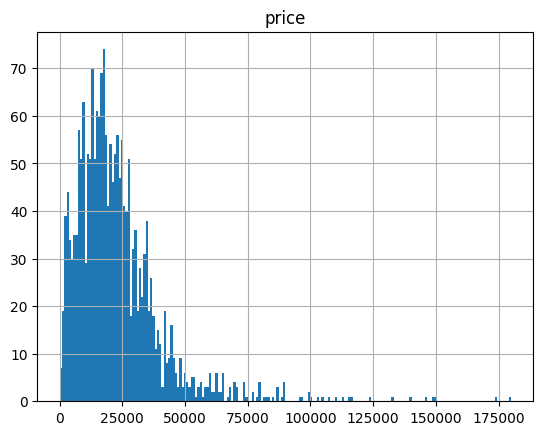

In [8]:
df.hist(column='price', bins=200)

The distribution roughly follows a log-normal distribution with a steep initial ascend, an early peak and a long right tail that asymptotically approaches zero.

Visualize the relationship between the age  and its price using Pandas scatter plot method.

<Axes: xlabel='age', ylabel='price'>

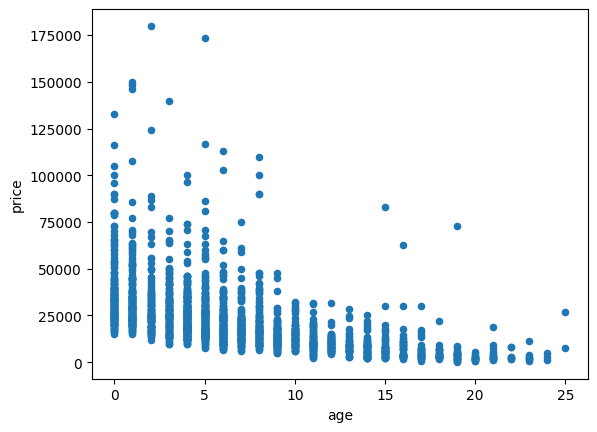

In [9]:
df.plot(y="price", x="age", kind="scatter")

Change the color of the scatter markers to your preferred color (the same color for all markers)

<Axes: xlabel='age', ylabel='price'>

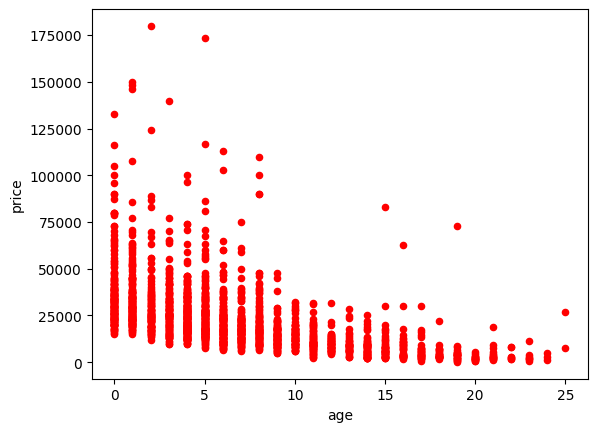

In [10]:
df.plot.scatter(y="price", x="age", c="red")

Add the argument `s='horsepower'` to your Pandas scatter plot. What do you observe?

<Axes: xlabel='age', ylabel='price'>

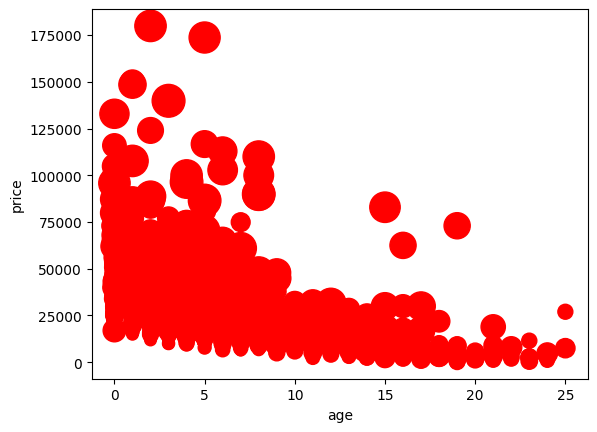

In [11]:
df.plot.scatter(y="price", x="age", c="red", s="horsepower")

S seems to set the size of each point by the value of the column passed. It's pretty clear taht cars with higher price tend to have more horsepower. Apart from that the plot is sadly too cluttered to make out specifics.

Now change the argument to `s='fuel_type'`. What do you observe? Can you explain the difference to the previous plot?

ValueError: s must be a scalar, or float array-like with the same size as x and y

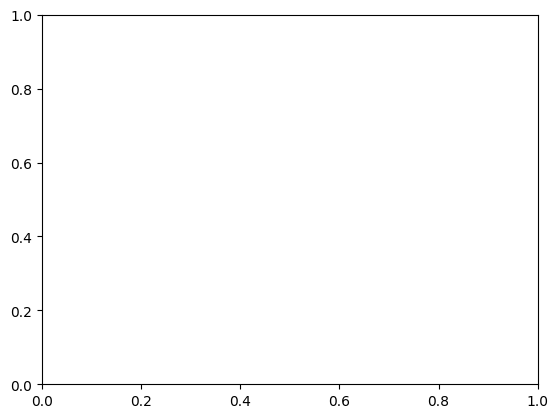

In [12]:
df.plot.scatter(y="price", x="age", c="red", s="fuel_type")

I get an error with fuel_type because it is no scalar, or float value. Different fuel types are no numeric values, and cannot be sorted. Because "Hybrid" is not inherently greater than "Petrol" assigning different sizes of dots to each does not make sense. A much more sensible approach would be to assign different colors to each fuel type.

# Task 3: Seaborn Plotting

Create a scatterplot using **Seaborn** that shows the relationship between the `age` and the `price` of a car, but using different colors for each `fuel_type`. What pattern do you observe?

<Axes: xlabel='age', ylabel='price'>

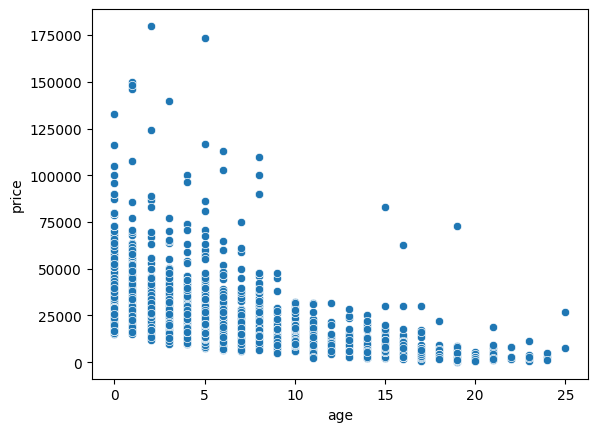

In [13]:
sns.scatterplot(data=df,x="age", y="price")

Use the argument `palette` to change the color scheme of your plot. See [here](https://seaborn.pydata.org/tutorial/color_palettes.html) for more details on available color palettes.
Also, make your visualization self explanatory by adding a title and clearer axis labels. 

Text(0, 0.5, 'Price (EUR)')

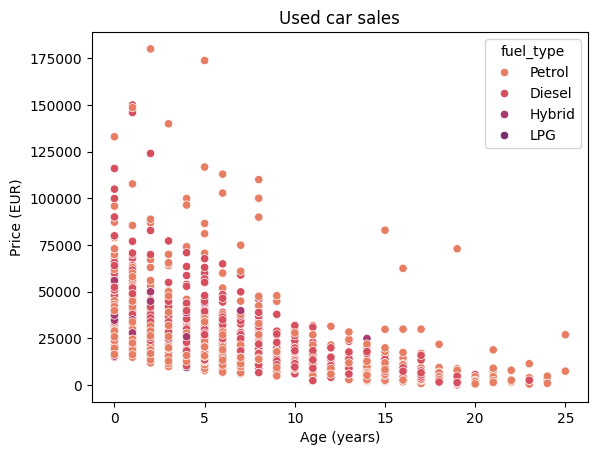

In [14]:
sns.scatterplot(data=df,x="age",y="price",hue="fuel_type",palette="flare")
plt.title("Used car sales")
plt.xlabel("Age (years)")
plt.ylabel("Price (EUR)")

The amount of data points in the scatterplot seems overwhelming. Create an alternative scatterplot, where each `fuel_type` is represented in its own column.

Hint: the normal `scatterplot` function does not allow you to do this. You will need to use the corresponding figure-level function for scatterplots in Seaborn. You can find more information about this in the [Seaborn documentation](https://seaborn.pydata.org/tutorial/relational.html#relational-plotting-with-relplot).

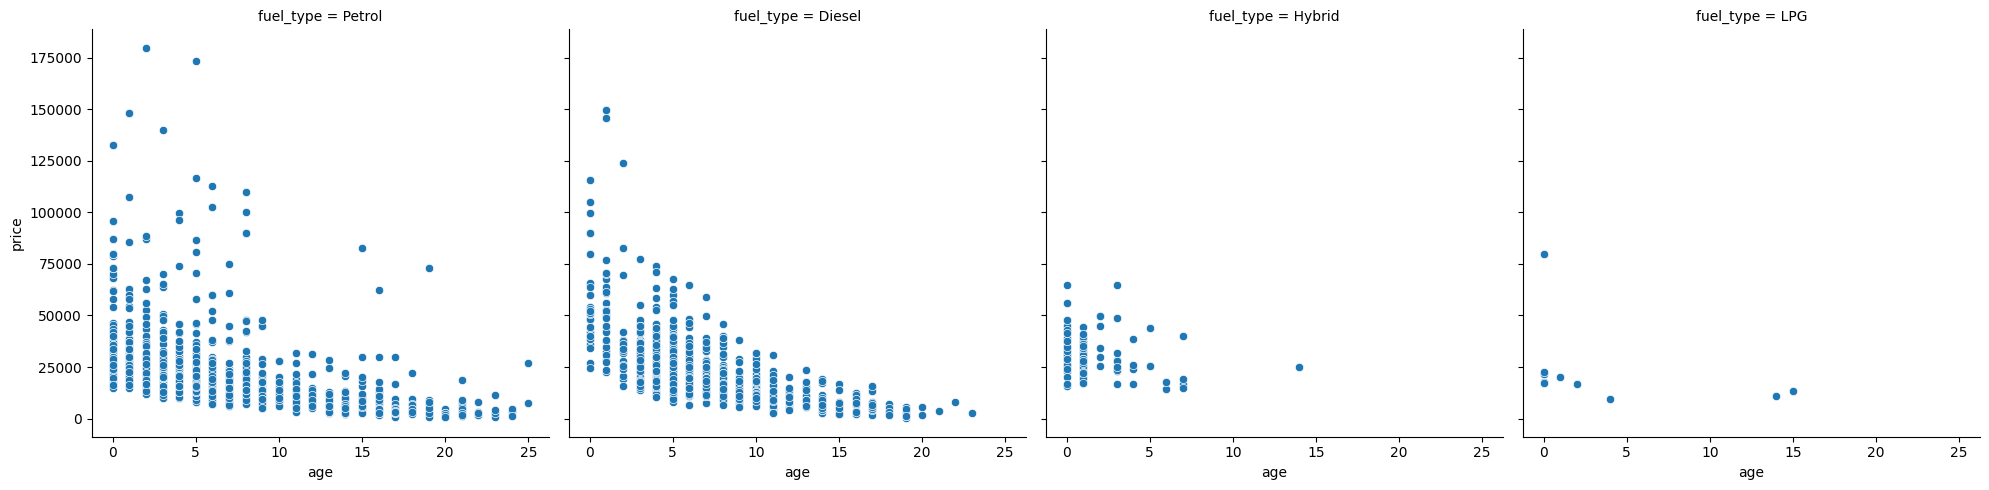

In [15]:
sns.relplot(data=df,x="age",y="price",col="fuel_type")

Create 1 figure that contains 2 histograms using Seaborn: one for the variable `mileage`, and one for the variable `fuel_consumption`. Add a title to each histogram, and a common title for the whole figure.

Text(0.5, 0.98, 'Vehicle Statistics: Mileage and Fuel consumption')

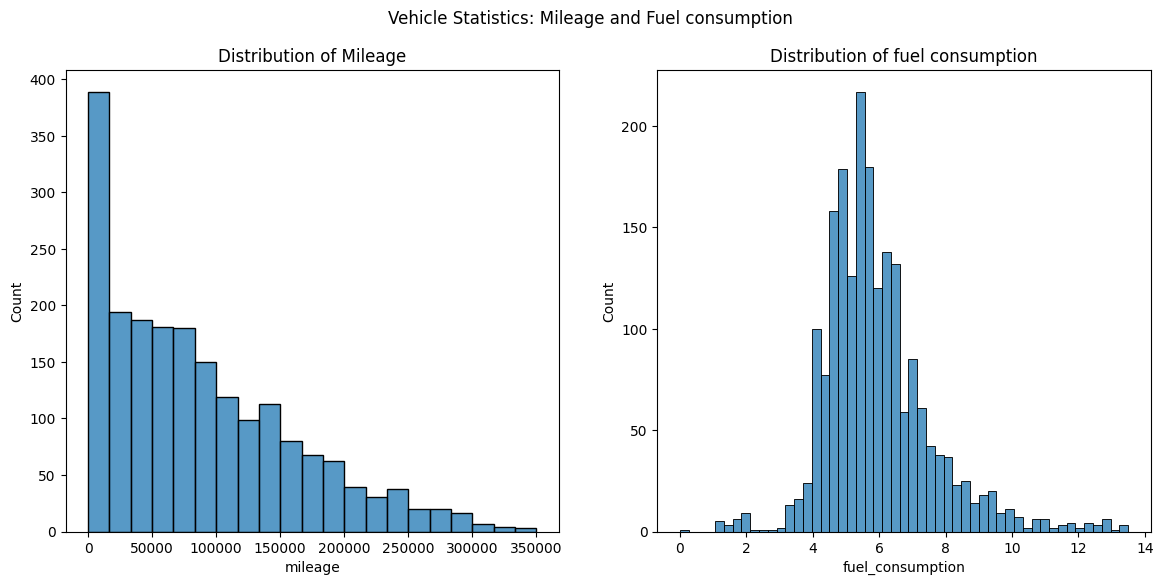

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(data=df, x="mileage", ax=axes[0])
axes[0].set_title("Distribution of Mileage")

sns.histplot(data=df, x="fuel_consumption", ax=axes[1])
axes[1].set_title("Distribution of fuel consumption")

fig.suptitle("Vehicle Statistics: Mileage and Fuel consumption")

Save the last figure, first as a `.jpg` file, then as a `.svg` file. Open the files and inspect them. What are the difference between the two formats?

In [17]:
fig.savefig(fname=cwd.joinpath("plots/svg_plot.svg"), format="svg")

In [18]:
fig.savefig(fname=cwd.joinpath("plots/jpg_plot.jpg"), format="jpg")

SVG stores images as mathematical instructions like shapes,paths and curves.
JPG stores the image as a fixed grid of pixels. 

SVG can be scaled well while JPG is a static snapshot at a particular resolution. 

SVG can have quite a large filesize if the graphics get complex while JPG is fairly consistent in filesize.

# Task 4: Matplotlibs two interfaces

Translate the following Pyplot code into object-oriented code 

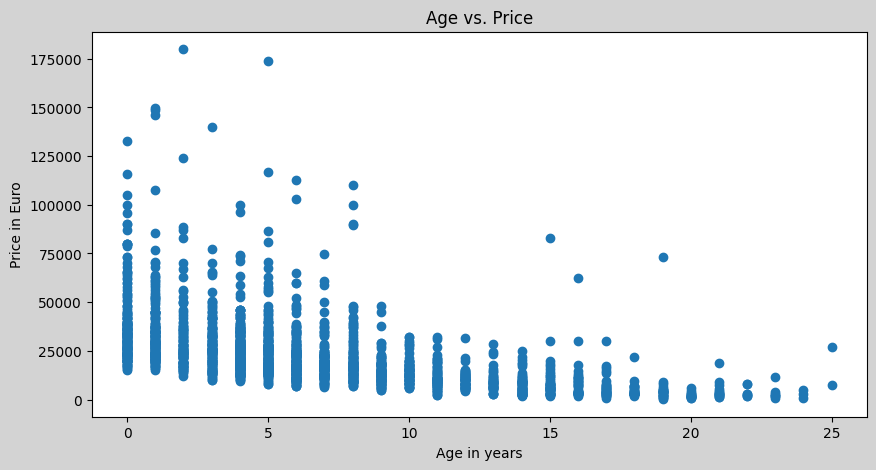

In [19]:
plt.figure(figsize=(10, 5), facecolor='lightgrey')
plt.scatter(df.age, df.price)   # this assumes that your dataframe is called "df"
plt.title("Age vs. Price")
plt.xlabel("Age in years")
plt.ylabel("Price in Euro")
plt.savefig("scatterplot.png")

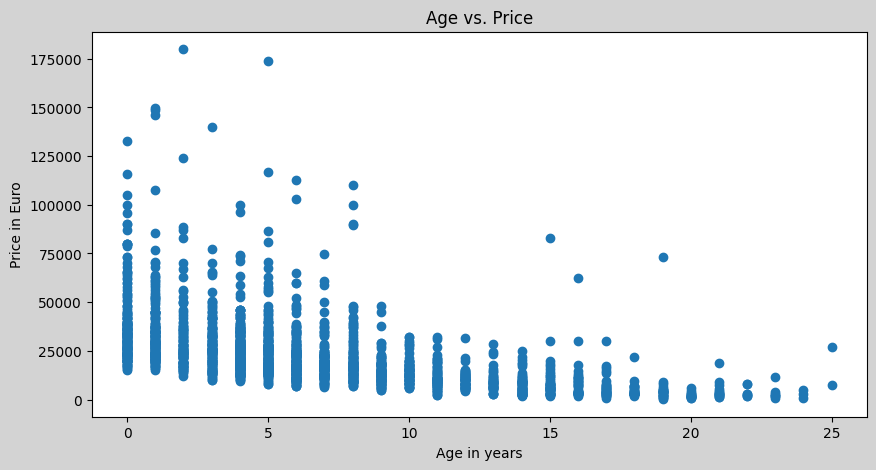

In [20]:
fig, ax = plt.subplots(figsize=(10,5))
fig.set_facecolor('lightgrey')

ax.scatter(df['age'], df['price'])

ax.set_title("Age vs. Price")
ax.set_xlabel("Age in years")
ax.set_ylabel("Price in Euro")

fig.savefig("scatterplot.png")

# Task 5: Test your own hypothesis

In the last part of exercise 1, you have stated different hypotheses about the data. Now, pick one hypothesis and try to confirm or reject it by creating a suitable visualization. Use Seaborn for this.

<Axes: xlabel='age', ylabel='price'>

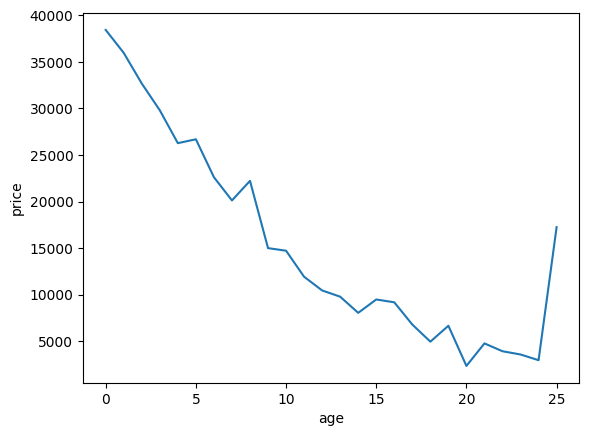

In [21]:
# Do car prices drop with age?
age_price_average = df.groupby('age')['price'].mean().reset_index()

sns.lineplot(age_price_average, x='age', y='price')

In [22]:
df.groupby('age')['age'].count()

age
0     177
1     166
2     103
3     134
4     225
5     186
6     162
7     130
8     113
9      96
10     76
11     66
12     55
13     41
14     58
15     46
16     36
17     31
18     26
19     24
20     15
21     15
22      7
23      7
24      3
25      2
Name: age, dtype: int64

Answer: The plot indicates that the price may indeed correlate with the age of the car. Although the data shows an outlier after 25 years. This may be because there are especially few data points with cars that age.